<a href="https://colab.research.google.com/github/Adriungs/Ciencia_de_datos/blob/main/Analisis_de_Datos/Proyecto_IPC_y_Salarios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
  <font size="5" color="black">
    <b><u>SALARIO Y IPC 2017 a 2026</u></b>
  </font>
</center>

##<u> Objetivo del Proyecto  </u>
En este proyecto voy a analizar el IPC y el Salario juntándolos para responder alguna pregunta macroeconómica de la Argentina y poder así crear una solución en base a los datos aca presentados.

#<u> Pregunta a responder </u>

¿En qué medida la inflación acumulada en Argentina afectó el poder adquisitivo de los trabajadores según su condición de formalidad (registrados vs. informales) durante el período analizado?

#<u> Métodos utilizados para el análisis de datos  </u>

* EDA
* Data cleaning with pandas
* Data Visualization
* Estadistica básica
##<u> Fuentes </u>

https://www.kaggle.com/learn/pandas

https://www.kaggle.com/learn/data-cleaning

https://www.kaggle.com/learn/data-visualization

https://colab.research.google.com/github/mateosuster/pythonungs/blob/master/codigos/pandas/Pr%C3%A1ctica_Visualizacion_de_datos.ipynb#scrollTo=IigPdM3EXKLL

https://colab.research.google.com/github/mateosuster/pythonungs/blob/master/codigos/manipulacion_de_datos/4_Manipulaci%C3%B3n_de_DataFrames.ipynb


##<u>Descripción de los campos</u>

 **SALARIOS:**
 * indice_salarios: Muestra la evolución promedio de los salarios de toda la economía argentina.

 * indice_salarios_registrado: Mide el promedio de los salarios de los trabajadores que están "en blanco" (empleo formal, con aportes jubilatorios y obra social). Suma tanto al sector privado como al estatal.  

 * indice_salarios_registrado_sector_privado: Mide específicamente la evolución de los sueldos de trabajadores en blanco que pertenecen a empresas privadas (fábricas, comercios, servicios, etc.).

 * indice_salarios_registrado_sector_publico: Mide la evolución de los sueldos de los empleados del Estado (incluye administración pública, salud, educación y seguridad a nivel nacional, provincial y municipal).

 * indice_salarios_no_registrado_sector_privado: Mide la evolución estimada de los salarios de los trabajadores "en negro" o informales.

**El IPC (Índice de Precios al Consumidor):**

El IPC (Índice de Precios al Consumidor) mide cuánto varía el costo de una "canasta" de bienes y servicios (comida, ropa, transporte, tarifas, etc.) que consumen los hogares.

* ipc_nacional: Es el número índice que representa el costo de la canasta a nivel de todo el país. Consolida los precios relevados en las 6 regiones estadísticas de Argentina (Pampeana, NOA, NEA, Cuyo, Patagonia y GBA).

* ipc_gba: Es el número índice pero acotado geográficamente a la región del Gran Buenos Aires (que incluye a la Ciudad Autónoma de Buenos Aires y los 24 partidos del conurbano bonaerense).

* ipc_nacional_tasa_variacion_mensual: Es el porcentaje en el que aumentó (o bajó) el IPC Nacional respecto al mes anterior. Este es el dato que comúnmente escuchamos en los noticieros como "la inflación del mes" a nivel país.

* ipc_gba_tasa_variacion_mensual: Es el porcentaje de aumento de precios mensual medido específicamente para la región de Gran Buenos Aires.

Los campos que terminan en _nacional o _gba a secas son números índice (por ejemplo: 1425.3). No te dicen un porcentaje directo, sino cuánto se acumuló respecto a un año base (por ejemplo, base diciembre 2016 = 100). Los que terminan en _tasa_variacion_mensual sí son el porcentaje directo de inflación de ese mes (por ejemplo: 2.1%). Lo mismo aplica para los índices de salarios.

---

#<u> CARGA DE DATOS</u>
Para empezar voy a cargar los datos via URL. Elegi esta fuente de datos asi cualquiera que vea el proyecto puede utilizarlos sin descargar dataframe externos.
Además el archivo necesita descargarse o subirse siempre que se reinicie la pc,sin embargo, las pymes y consultoras suelen necesitar cargar datos externos de sus propios archivos y por lo general se van a usar archivos temporales y no url

In [57]:
!wget "https://infra.datos.gob.ar/catalog/sspm/dataset/149/distribution/149.1/download/indice-salarios-periodicidad-mensual-base-octubre-2016.csv"

--2026-08-01 18:08:51--  https://infra.datos.gob.ar/catalog/sspm/dataset/149/distribution/149.1/download/indice-salarios-periodicidad-mensual-base-octubre-2016.csv
Resolving infra.datos.gob.ar (infra.datos.gob.ar)... 172.67.213.150, 104.21.45.117, 2606:4700:3032::6815:2d75, ...
Connecting to infra.datos.gob.ar (infra.datos.gob.ar)|172.67.213.150|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5976 (5.8K) [text/csv]
Saving to: ‘indice-salarios-periodicidad-mensual-base-octubre-2016.csv.1’

indice-salarios-per 100%[===================>]   5.84K  --.-KB/s    in 0s      

2026-08-01 18:08:51 (77.1 MB/s) - ‘indice-salarios-periodicidad-mensual-base-octubre-2016.csv.1’ saved [5976/5976]



In [58]:
!wget "https://infra.datos.gob.ar/catalog/sspm/dataset/145/distribution/145.3/download/indice-precios-al-consumidor-nivel-general-base-diciembre-2016-mensual.csv"

--2026-08-01 18:08:51--  https://infra.datos.gob.ar/catalog/sspm/dataset/145/distribution/145.3/download/indice-precios-al-consumidor-nivel-general-base-diciembre-2016-mensual.csv
Resolving infra.datos.gob.ar (infra.datos.gob.ar)... 172.67.213.150, 104.21.45.117, 2606:4700:3032::6815:2d75, ...
Connecting to infra.datos.gob.ar (infra.datos.gob.ar)|172.67.213.150|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 41193 (40K) [text/csv]
Saving to: ‘indice-precios-al-consumidor-nivel-general-base-diciembre-2016-mensual.csv.1’

indice-precios-al-c 100%[===================>]  40.23K  --.-KB/s    in 0s      

2026-08-01 18:08:51 (163 MB/s) - ‘indice-precios-al-consumidor-nivel-general-base-diciembre-2016-mensual.csv.1’ saved [41193/41193]



Se leen los archivos por separado y se prueba si funciono la lectura. El codigo va a leer los 5 primeros datos de cada columna

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
url1 = "/content/indice-salarios-periodicidad-mensual-base-octubre-2016.csv"
url2 ="/content/indice-precios-al-consumidor-nivel-general-base-diciembre-2016-mensual.csv"
print("------Indice de salario Mensual-----")
df_sal = pd.read_csv(url1)
print(df_sal.head())
print("-----Indice de precios al consumidor Mensual-----")
df_ipc = pd.read_csv(url2)
print(df_ipc.head())

------Indice de salario Mensual-----
  indice_tiempo  indice_salarios  indice_salarios_registrado  \
0    2015-10-01              NaN                       74.44   
1    2015-11-01              NaN                       76.07   
2    2015-12-01              NaN                       77.29   
3    2016-01-01              NaN                       78.38   
4    2016-02-01              NaN                       79.42   

   indice_salarios_registrado_sector_privado  \
0                                      73.97   
1                                      75.95   
2                                      77.36   
3                                      78.93   
4                                      80.04   

   indice_salarios_registrado_sector_publico  \
0                                      75.24   
1                                      76.28   
2                                      77.18   
3                                      77.46   
4                                      78.36   



#<u> Exploración previa a la integración</u>

Realice de nuevo .head() pero con otra vista mas ordenada para tener un panorama mas claro. Intento ver las columnas y los datos que sean semejantes entre los dos dataframes

In [60]:
df_sal.head()



,indice_tiempo,indice_salarios,indice_salarios_registrado,indice_salarios_registrado_sector_privado,indice_salarios_registrado_sector_publico,indice_salarios_no_registrado_sector_privado
0,2015-10-01,NaN,74.44,73.97,75.24,NaN
1,2015-11-01,NaN,76.07,75.95,76.28,NaN
2,2015-12-01,NaN,77.29,77.36,77.18,NaN
3,2016-01-01,NaN,78.38,78.93,77.46,NaN
4,2016-02-01,NaN,79.42,80.04,78.36,NaN


In [61]:
df_ipc.head()

,indice_tiempo,ipc_ng_nacional,ipc_ng_gba,ipc_ng_pampeana,ipc_ng_nea,ipc_ng_noa,ipc_ng_cuyo,ipc_ng_patagonia,ipc_ng_nacional_tasa_variacion_mensual,ipc_ng_gba_tasa_variacion_mensual,...,ipc_ng_noa_tasa_variacion_mensual,ipc_ng_cuyo_tasa_variacion_mensual,ipc_ng_patagonia_tasa_variacion_mensual,ipc_ng_nacional_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_gba_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_pampeana_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_nea_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_noa_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_cuyo_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_patagonia_tasa_variacion_acumulada_dic_ano_anterior
0,2016-12-01,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-01,101.5859,101.3130,101.7874,101.6727,101.6014,101.7074,102.5593,0.015859,0.013130,...,0.016014,0.017074,0.025593,0.015859,0.013130,0.017874,0.016727,0.016014,0.017074,0.025593
2,2017-02-01,103.6859,103.8085,103.5312,103.4617,103.7115,103.2652,104.2827,0.020672,0.024632,...,0.020768,0.015316,0.016804,0.036859,0.038085,0.035312,0.034617,0.037115,0.032652,0.042827
3,2017-03-01,106.1476,106.2627,105.8173,105.9880,107.0550,105.9238,106.5167,0.023742,0.023642,...,0.032238,0.025745,0.021423,0.061476,0.062627,0.058173,0.059880,0.070550,0.059238,0.065167
4,2017-04-01,108.9667,109.0613,108.6912,108.3473,109.9626,109.4506,108.6517,0.026558,0.026337,...,0.027160,0.033296,0.020044,0.089667,0.090613,0.086912,0.083473,0.099626,0.094506,0.086517


###Que columnas tienen en común
Verifique las columnas por lista de cada dataframe y encontre que el indice_tiempo es el que puedo usar para unir ambos dataframe y empezar a explorar y limpiar los datos antes de su visualización

In [62]:
print(df_sal.columns)
print(df_ipc.columns)


Index(['indice_tiempo', 'indice_salarios', 'indice_salarios_registrado',
       'indice_salarios_registrado_sector_privado',
       'indice_salarios_registrado_sector_publico',
       'indice_salarios_no_registrado_sector_privado'],
      dtype='object')
Index(['indice_tiempo', 'ipc_ng_nacional', 'ipc_ng_gba', 'ipc_ng_pampeana',
       'ipc_ng_nea', 'ipc_ng_noa', 'ipc_ng_cuyo', 'ipc_ng_patagonia',
       'ipc_ng_nacional_tasa_variacion_mensual',
       'ipc_ng_gba_tasa_variacion_mensual',
       'ipc_ng_pampeana_tasa_variacion_mensual',
       'ipc_ng_nea_tasa_variacion_mensual',
       'ipc_ng_noa_tasa_variacion_mensual',
       'ipc_ng_cuyo_tasa_variacion_mensual',
       'ipc_ng_patagonia_tasa_variacion_mensual',
       'ipc_ng_nacional_tasa_variacion_acumulada_dic_ano_anterior',
       'ipc_ng_gba_tasa_variacion_acumulada_dic_ano_anterior',
       'ipc_ng_pampeana_tasa_variacion_acumulada_dic_ano_anterior',
       'ipc_ng_nea_tasa_variacion_acumulada_dic_ano_anterior',
       'ipc_

###¿Hay duplicados?
Realice una breve exploración de datos en la columna indice_tiempo de ambos dataframe y ver si encontraba inconsistencias y similitudes antes de unir los dataframes

In [63]:
print(df_sal["indice_tiempo"].duplicated().sum())
print(df_ipc["indice_tiempo"].duplicated().sum())

0
0


###¿Qué períodos cubren?

In [64]:
print(df_sal["indice_tiempo"].min(), df_sal["indice_tiempo"].max())
print(df_ipc["indice_tiempo"].min(), df_ipc["indice_tiempo"].max())

2015-10-01 2026-04-01
2016-12-01 2026-06-01


Aca mire para ver como estaba organizado en este caso %Y_%M_%D

In [65]:
print(df_sal["indice_tiempo"].head())
print(df_sal["indice_tiempo"].tail())

print(df_ipc["indice_tiempo"].head())
print(df_ipc["indice_tiempo"].tail())

0    2015-10-01
1    2015-11-01
2    2015-12-01
3    2016-01-01
4    2016-02-01
Name: indice_tiempo, dtype: object
122    2025-12-01
123    2026-01-01
124    2026-02-01
125    2026-03-01
126    2026-04-01
Name: indice_tiempo, dtype: object
0    2016-12-01
1    2017-01-01
2    2017-02-01
3    2017-03-01
4    2017-04-01
Name: indice_tiempo, dtype: object
110    2026-02-01
111    2026-03-01
112    2026-04-01
113    2026-05-01
114    2026-06-01
Name: indice_tiempo, dtype: object


###Coincide el Dtype para el análisis?
Como anteriormente nos mostraba que no lo convertimos y lo adaptamos al dtype que si nos sirve

In [66]:
df_sal["indice_tiempo"] = pd.to_datetime(df_sal["indice_tiempo"])
df_ipc["indice_tiempo"] = pd.to_datetime(df_ipc["indice_tiempo"])
print(df_sal.info())
print(df_ipc.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 6 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   indice_tiempo                                 127 non-null    datetime64[ns]
 1   indice_salarios                               115 non-null    float64       
 2   indice_salarios_registrado                    127 non-null    float64       
 3   indice_salarios_registrado_sector_privado     127 non-null    float64       
 4   indice_salarios_registrado_sector_publico     127 non-null    float64       
 5   indice_salarios_no_registrado_sector_privado  115 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 6.1 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 22 columns):
 #   Column                                                      Non-Nu

Hasta aca encontre que no habia fechas duplicadas, pero que todas las fechas estaban en formato object y las converti a datetime64 para su posterior manipulación si surgen inconsistencias.Además puedo manipular las fechas de mejor manera con funciones de pandas

<center>
  <font size="5" color="black">
    <b><u>EXPLORACIÓN</u></b>
  </font>
</center>


---
Esta parte es importante porque primero voy a ver el total de datos de cada dataframe  y despues voy a ver la cantidad de datos de los dataframe unidos tanto con inner y left.
En este caso use left ya que en la unión necesito datos que se encuentren en sus mismas fechas para analizarlos.
Concat no me ordenaba los datos y con inner si bien me traia todos los datos no me aportaban de nada los datos con NaN que me dejaba.

filas, columnas

(127, 6) salario individual

(114, 22) ipc individual

(113, 27) ipc y salario juntos con inner

(127, 27) ipc y salario juntos con left(deja todo)

In [67]:
print(df_sal.shape)
print(df_ipc.shape)

df_inner = pd.merge(df_sal, df_ipc, on="indice_tiempo", how="inner")
print(df_inner.shape)

df_left = pd.merge(df_sal, df_ipc, on="indice_tiempo", how="left")
print(df_left.shape)

(127, 6)
(115, 22)
(113, 27)
(127, 27)


In [68]:
df = pd.merge(df_sal, df_ipc, on="indice_tiempo", how="inner")

###Cuantos valores nulos hay en cada columna?

In [69]:
df.isnull().sum()

,0
indice_tiempo,0
indice_salarios,0
indice_salarios_registrado,0
indice_salarios_registrado_sector_privado,0
indice_salarios_registrado_sector_publico,0
indice_salarios_no_registrado_sector_privado,0
ipc_ng_nacional,0
ipc_ng_gba,0
ipc_ng_pampeana,0
ipc_ng_nea,0


In [70]:
df["indice_tiempo"].duplicated().sum()

np.int64(0)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 27 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   indice_tiempo                                               113 non-null    datetime64[ns]
 1   indice_salarios                                             113 non-null    float64       
 2   indice_salarios_registrado                                  113 non-null    float64       
 3   indice_salarios_registrado_sector_privado                   113 non-null    float64       
 4   indice_salarios_registrado_sector_publico                   113 non-null    float64       
 5   indice_salarios_no_registrado_sector_privado                113 non-null    float64       
 6   ipc_ng_nacional                                             113 non-null    float64       
 7   ipc_ng_gba                

In [72]:
df.dtypes

,0
indice_tiempo,datetime64[ns]
indice_salarios,float64
indice_salarios_registrado,float64
indice_salarios_registrado_sector_privado,float64
indice_salarios_registrado_sector_publico,float64
indice_salarios_no_registrado_sector_privado,float64
ipc_ng_nacional,float64
ipc_ng_gba,float64
ipc_ng_pampeana,float64
ipc_ng_nea,float64


In [73]:
df= df.sort_values("indice_tiempo").reset_index(drop=True)

In [74]:
df.head()

,indice_tiempo,indice_salarios,indice_salarios_registrado,indice_salarios_registrado_sector_privado,indice_salarios_registrado_sector_publico,indice_salarios_no_registrado_sector_privado,ipc_ng_nacional,ipc_ng_gba,ipc_ng_pampeana,ipc_ng_nea,...,ipc_ng_noa_tasa_variacion_mensual,ipc_ng_cuyo_tasa_variacion_mensual,ipc_ng_patagonia_tasa_variacion_mensual,ipc_ng_nacional_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_gba_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_pampeana_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_nea_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_noa_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_cuyo_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_patagonia_tasa_variacion_acumulada_dic_ano_anterior
0,2016-12-01,102.79,102.69,102.89,102.37,103.20,100.0000,100.0000,100.0000,100.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-01,104.38,104.98,106.34,102.68,102.00,101.5859,101.3130,101.7874,101.6727,...,0.016014,0.017074,0.025593,0.015859,0.013130,0.017874,0.016727,0.016014,0.017074,0.025593
2,2017-02-01,105.76,105.97,107.69,103.08,104.94,103.6859,103.8085,103.5312,103.4617,...,0.020768,0.015316,0.016804,0.036859,0.038085,0.035312,0.034617,0.037115,0.032652,0.042827
3,2017-03-01,108.82,108.50,109.26,107.24,110.08,106.1476,106.2627,105.8173,105.9880,...,0.032238,0.025745,0.021423,0.061476,0.062627,0.058173,0.059880,0.070550,0.059238,0.065167
4,2017-04-01,112.63,112.14,112.93,110.81,114.61,108.9667,109.0613,108.6912,108.3473,...,0.027160,0.033296,0.020044,0.089667,0.090613,0.086912,0.083473,0.099626,0.094506,0.086517


In [75]:
df.tail()

,indice_tiempo,indice_salarios,indice_salarios_registrado,indice_salarios_registrado_sector_privado,indice_salarios_registrado_sector_publico,indice_salarios_no_registrado_sector_privado,ipc_ng_nacional,ipc_ng_gba,ipc_ng_pampeana,ipc_ng_nea,...,ipc_ng_noa_tasa_variacion_mensual,ipc_ng_cuyo_tasa_variacion_mensual,ipc_ng_patagonia_tasa_variacion_mensual,ipc_ng_nacional_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_gba_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_pampeana_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_nea_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_noa_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_cuyo_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_patagonia_tasa_variacion_acumulada_dic_ano_anterior
108,2025-12-01,7969.60,7794.68,8441.00,6710.79,8672.31,10121.3715,10115.6707,10107.6074,9968.3824,...,0.026060,0.029574,0.025710,0.315488,0.317355,0.314849,0.288362,0.314259,0.316711,0.329339
109,2026-01-01,8171.66,7952.81,8620.98,6832.27,9050.90,10413.0309,10395.7458,10400.4968,10350.7115,...,0.028488,0.029858,0.028796,0.028816,0.027687,0.028977,0.038354,0.028488,0.029858,0.028796
110,2026-02-01,8370.04,8096.38,8755.26,6991.42,9469.49,10714.6255,10667.6896,10714.2389,10676.7516,...,0.035414,0.034088,0.029801,0.058614,0.054571,0.060017,0.071062,0.064911,0.064963,0.059455
111,2026-03-01,8654.99,8341.11,8935.48,7344.33,9916.02,11077.0608,11031.5404,11065.4568,11119.3596,...,0.039525,0.032054,0.024773,0.094423,0.090540,0.094765,0.115463,0.107001,0.099100,0.085701
112,2026-04-01,8978.10,8628.95,9292.93,7515.45,10380.80,11363.0904,11336.5576,11330.2697,11423.3251,...,0.025387,0.021236,0.026199,0.122683,0.120693,0.120965,0.145956,0.135105,0.122440,0.114145


In [76]:
df.describe()

,indice_tiempo,indice_salarios,indice_salarios_registrado,indice_salarios_registrado_sector_privado,indice_salarios_registrado_sector_publico,indice_salarios_no_registrado_sector_privado,ipc_ng_nacional,ipc_ng_gba,ipc_ng_pampeana,ipc_ng_nea,...,ipc_ng_noa_tasa_variacion_mensual,ipc_ng_cuyo_tasa_variacion_mensual,ipc_ng_patagonia_tasa_variacion_mensual,ipc_ng_nacional_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_gba_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_pampeana_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_nea_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_noa_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_cuyo_tasa_variacion_acumulada_dic_ano_anterior,ipc_ng_patagonia_tasa_variacion_acumulada_dic_ano_anterior
count,113,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,...,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000
mean,2021-08-01 00:25:29.203539712,1877.152655,1919.573717,2045.935487,1707.661858,1706.723451,2449.070720,2432.643716,2456.550211,2467.835012,...,0.043850,0.043877,0.043803,0.344563,0.345074,0.343452,0.337562,0.349093,0.345805,0.348094
min,2016-12-01 00:00:00,102.790000,102.690000,102.890000,102.370000,102.000000,100.000000,100.000000,100.000000,100.000000,...,0.009463,0.009671,0.006154,0.015859,0.013130,0.017874,0.016727,0.016014,0.015014,0.025060
25%,2019-04-01 00:00:00,191.110000,191.670000,193.470000,188.650000,188.440000,213.051700,212.446900,213.048900,212.697300,...,0.023668,0.023397,0.025187,0.117307,0.115495,0.114004,0.119248,0.128014,0.115401,0.112733
50%,2021-08-01 00:00:00,423.410000,436.400000,451.640000,410.820000,371.240000,510.394200,497.937100,518.532000,529.660400,...,0.033463,0.033769,0.032797,0.221276,0.220006,0.220326,0.214443,0.229981,0.224442,0.227282
75%,2023-12-01 00:00:00,2348.790000,2546.200000,2648.870000,2374.020000,1555.650000,3533.192200,3456.642600,3584.843900,3795.525000,...,0.050939,0.051049,0.048730,0.442998,0.436741,0.445745,0.445331,0.446131,0.452032,0.468134
max,2026-04-01 00:00:00,8978.100000,8628.950000,9292.930000,7515.450000,10380.800000,11363.090400,11336.557600,11330.269700,11423.325100,...,0.252287,0.258461,0.243087,2.114076,2.101419,2.128476,2.194720,2.124740,2.072188,2.077188
std,NaN,2630.898447,2635.560981,2846.393596,2283.013568,2684.618280,3440.602067,3430.634839,3440.712569,3428.151539,...,0.035725,0.036511,0.036399,0.351525,0.355834,0.349145,0.341736,0.346949,0.346444,0.356081


In [77]:
df.columns.tolist()

['indice_tiempo',
 'indice_salarios',
 'indice_salarios_registrado',
 'indice_salarios_registrado_sector_privado',
 'indice_salarios_registrado_sector_publico',
 'indice_salarios_no_registrado_sector_privado',
 'ipc_ng_nacional',
 'ipc_ng_gba',
 'ipc_ng_pampeana',
 'ipc_ng_nea',
 'ipc_ng_noa',
 'ipc_ng_cuyo',
 'ipc_ng_patagonia',
 'ipc_ng_nacional_tasa_variacion_mensual',
 'ipc_ng_gba_tasa_variacion_mensual',
 'ipc_ng_pampeana_tasa_variacion_mensual',
 'ipc_ng_nea_tasa_variacion_mensual',
 'ipc_ng_noa_tasa_variacion_mensual',
 'ipc_ng_cuyo_tasa_variacion_mensual',
 'ipc_ng_patagonia_tasa_variacion_mensual',
 'ipc_ng_nacional_tasa_variacion_acumulada_dic_ano_anterior',
 'ipc_ng_gba_tasa_variacion_acumulada_dic_ano_anterior',
 'ipc_ng_pampeana_tasa_variacion_acumulada_dic_ano_anterior',
 'ipc_ng_nea_tasa_variacion_acumulada_dic_ano_anterior',
 'ipc_ng_noa_tasa_variacion_acumulada_dic_ano_anterior',
 'ipc_ng_cuyo_tasa_variacion_acumulada_dic_ano_anterior',
 'ipc_ng_patagonia_tasa_variacio

Realice primero la exploracion de datos en las dos columnas de esta formas veo la información general conjunta antes de elegir columnas para su limpieza

<center>
  <font size="5" color="black">
    <b><u>LIMPIEZA</u></b>
  </font>
</center>


Realizamos una copia del dataset sobre el cual vamos a trabajar para no alterar los datos originales

In [78]:
df_limpieza = df[['indice_tiempo',
 'indice_salarios',
 'indice_salarios_registrado',
 'indice_salarios_registrado_sector_privado',
 'indice_salarios_registrado_sector_publico',
 'indice_salarios_no_registrado_sector_privado',
 'ipc_ng_nacional',
 'ipc_ng_gba',
 'ipc_ng_nacional_tasa_variacion_mensual',
 'ipc_ng_gba_tasa_variacion_mensual']].copy()

df_limpieza.head()

,indice_tiempo,indice_salarios,indice_salarios_registrado,indice_salarios_registrado_sector_privado,indice_salarios_registrado_sector_publico,indice_salarios_no_registrado_sector_privado,ipc_ng_nacional,ipc_ng_gba,ipc_ng_nacional_tasa_variacion_mensual,ipc_ng_gba_tasa_variacion_mensual
0,2016-12-01,102.79,102.69,102.89,102.37,103.20,100.0000,100.0000,NaN,NaN
1,2017-01-01,104.38,104.98,106.34,102.68,102.00,101.5859,101.3130,0.015859,0.013130
2,2017-02-01,105.76,105.97,107.69,103.08,104.94,103.6859,103.8085,0.020672,0.024632
3,2017-03-01,108.82,108.50,109.26,107.24,110.08,106.1476,106.2627,0.023742,0.023642
4,2017-04-01,112.63,112.14,112.93,110.81,114.61,108.9667,109.0613,0.026558,0.026337


###Identifique si habia ceros

In [79]:
cols = ['indice_tiempo',
 'indice_salarios',
 'indice_salarios_registrado',
 'indice_salarios_registrado_sector_privado',
 'indice_salarios_registrado_sector_publico',
 'indice_salarios_no_registrado_sector_privado',
 'ipc_ng_nacional',
 'ipc_ng_gba',
 'ipc_ng_nacional_tasa_variacion_mensual',
 'ipc_ng_gba_tasa_variacion_mensual']

(df_limpieza[cols] == 0).sum()

,0
indice_tiempo,0
indice_salarios,0
indice_salarios_registrado,0
indice_salarios_registrado_sector_privado,0
indice_salarios_registrado_sector_publico,0
indice_salarios_no_registrado_sector_privado,0
ipc_ng_nacional,0
ipc_ng_gba,0
ipc_ng_nacional_tasa_variacion_mensual,0
ipc_ng_gba_tasa_variacion_mensual,0


In [80]:
df_limpieza.isna().sum()

,0
indice_tiempo,0
indice_salarios,0
indice_salarios_registrado,0
indice_salarios_registrado_sector_privado,0
indice_salarios_registrado_sector_publico,0
indice_salarios_no_registrado_sector_privado,0
ipc_ng_nacional,0
ipc_ng_gba,0
ipc_ng_nacional_tasa_variacion_mensual,1
ipc_ng_gba_tasa_variacion_mensual,1


In [81]:
df_limpieza[df_limpieza['ipc_ng_nacional_tasa_variacion_mensual'].isna()]

,indice_tiempo,indice_salarios,indice_salarios_registrado,indice_salarios_registrado_sector_privado,indice_salarios_registrado_sector_publico,indice_salarios_no_registrado_sector_privado,ipc_ng_nacional,ipc_ng_gba,ipc_ng_nacional_tasa_variacion_mensual,ipc_ng_gba_tasa_variacion_mensual
0,2016-12-01,102.79,102.69,102.89,102.37,103.2,100.0,100.0,NaN,NaN


En este caso la primera observación de la tasa de variación mensual presenta un valor nulo debido a que no existe un período previo para calcular la variación. Es decir:


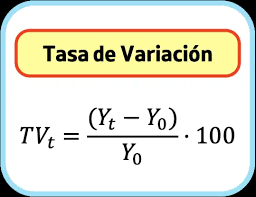

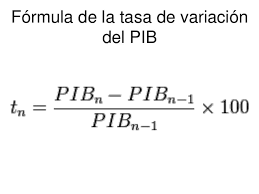


Esas son las formulas para buscar la tasa de variación

----
Esta es otra forma de buscar los index que tienen nulos:

In [82]:
print(df_limpieza[df_limpieza["ipc_ng_nacional_tasa_variacion_mensual"].isna()].index)
print(df_limpieza[df_limpieza["ipc_ng_gba_tasa_variacion_mensual"].isna()].index)

Index([0], dtype='int64')
Index([0], dtype='int64')


In [83]:
df_limpieza.rename(columns={
"ipc_ng_nacional": "ipc_nacional",
"ipc_ng_gba": "ipc_gba",
'ipc_ng_nacional': 'ipc_nacional',
'ipc_ng_gba': 'ipc_gba',
'ipc_ng_nacional_tasa_variacion_mensual': 'ipc_nacional_tasa_variacion_mensual',
'ipc_ng_gba_tasa_variacion_mensual': 'ipc_gba_tasa_variacion_mensual',
 }, inplace=True)

In [84]:
(df_limpieza[["indice_salarios", "indice_salarios_registrado", "indice_salarios_registrado_sector_privado", "indice_salarios_registrado_sector_publico", "indice_salarios_no_registrado_sector_privado", "ipc_nacional", "ipc_gba", "ipc_nacional_tasa_variacion_mensual",	"ipc_gba_tasa_variacion_mensual"]] < 0).any()


,0
indice_salarios,False
indice_salarios_registrado,False
indice_salarios_registrado_sector_privado,False
indice_salarios_registrado_sector_publico,False
indice_salarios_no_registrado_sector_privado,False
ipc_nacional,False
ipc_gba,False
ipc_nacional_tasa_variacion_mensual,False
ipc_gba_tasa_variacion_mensual,False


Aca me salto un error de Index y me habia olvidado de guardar en la variable asi que tuve que investigar de nuevo las columnas y recién aca me pude dar cuenta. Sin embargo, no le puse variable le puse inplace = True que sirve para guardar en el dataframe directamente

In [85]:
df_limpieza.columns.tolist()


['indice_tiempo',
 'indice_salarios',
 'indice_salarios_registrado',
 'indice_salarios_registrado_sector_privado',
 'indice_salarios_registrado_sector_publico',
 'indice_salarios_no_registrado_sector_privado',
 'ipc_nacional',
 'ipc_gba',
 'ipc_nacional_tasa_variacion_mensual',
 'ipc_gba_tasa_variacion_mensual']

En caso de que hubiese encontrado numeros negativos podria poner los siguientes codigos=

df[(df[["columna1", "columana2", "columna3"]] < 0).any(axis=1)]

Ya no te da un bool que te dice si hay nulos o no en la columna, sino que axis = 1 explora la columna fila por fila y te dice que fila tiene valores menores a 0.


---
Siguiendo con la limpieza intento identificar outliers lo que me lleva al análisis de gráficos, como primer instancia con plotlib hago una gráfico de serie de tiempo del indice_salarios

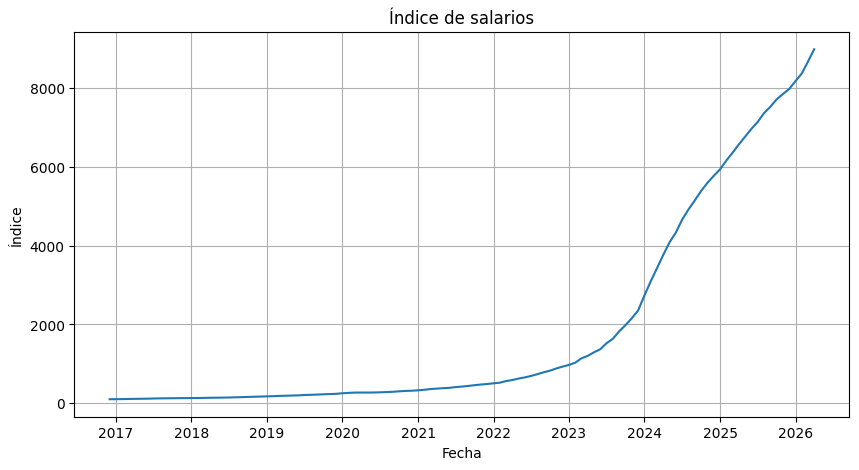

In [86]:
plt.figure(figsize=(10,5))
plt.plot(df_limpieza["indice_tiempo"], df_limpieza["indice_salarios"])
plt.title("Índice de salarios")
plt.xlabel("Fecha")
plt.ylabel("Índice")
plt.grid(True)
plt.show()

Aca puedo ver que el índice arranca en 102.79 en 2017 y llega a 8978.1 en 2026 es el efecto de la inflación acumulada en Argentina.

En 2017, el índice registraba valores cercanos a 102,79, mientras que hacia 2026 alcanzaba valores próximos a 8978,1.

El índice no mide “pesos” directamente, sino un nivel relativo de precios.


La subida implica que el poder adquisitivo de los salarios se erosiona si los ingresos nominales no crecieron al mismo ritmo.

In [87]:
df_limpieza["indice_salarios"].iloc[0]

np.float64(102.79)

In [88]:
df_limpieza["indice_salarios"].max()


8978.1

In [89]:
df_2026 = df_limpieza[df_limpieza["indice_tiempo"].dt.year == 2026]
df_2026["indice_salarios"].max()


8978.1

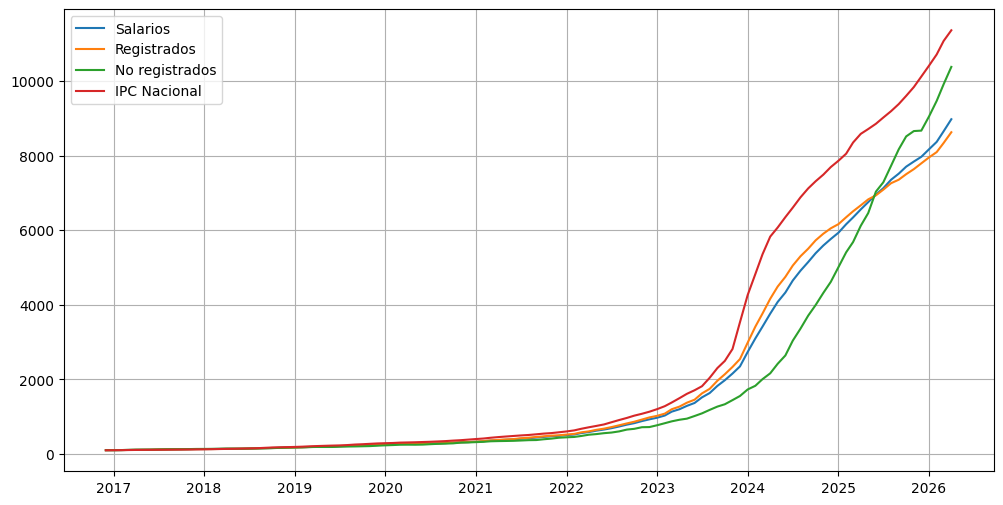

In [90]:
plt.figure(figsize=(12,6))

plt.plot(df_limpieza["indice_tiempo"], df_limpieza["indice_salarios"], label="Salarios")
plt.plot(df_limpieza["indice_tiempo"], df_limpieza["indice_salarios_registrado"], label="Registrados")
plt.plot(df_limpieza["indice_tiempo"], df_limpieza["indice_salarios_no_registrado_sector_privado"], label="No registrados")
plt.plot(df_limpieza["indice_tiempo"], df_limpieza["ipc_nacional"], label="IPC Nacional")

plt.legend()
plt.grid(True)
plt.show()

<Axes: >

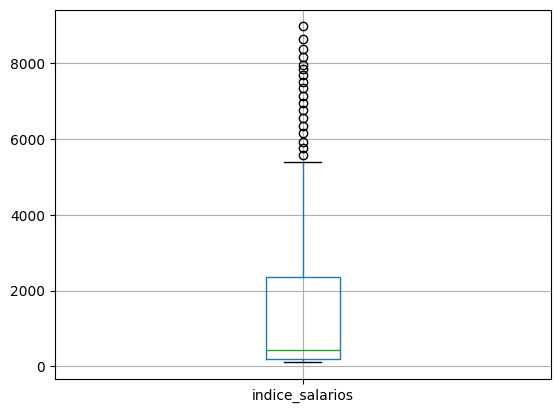

In [91]:
df_limpieza.boxplot(column="indice_salarios")

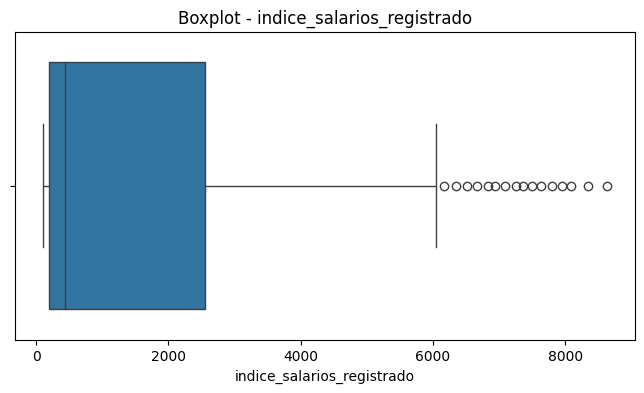

In [93]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_limpieza, x="indice_salarios_registrado")
plt.title("Boxplot - indice_salarios_registrado")
plt.show()

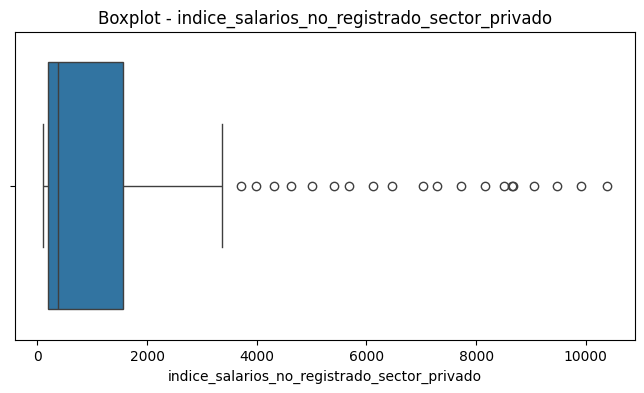

In [94]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_limpieza, x="indice_salarios_no_registrado_sector_privado")
plt.title("Boxplot - indice_salarios_no_registrado_sector_privado")
plt.show()

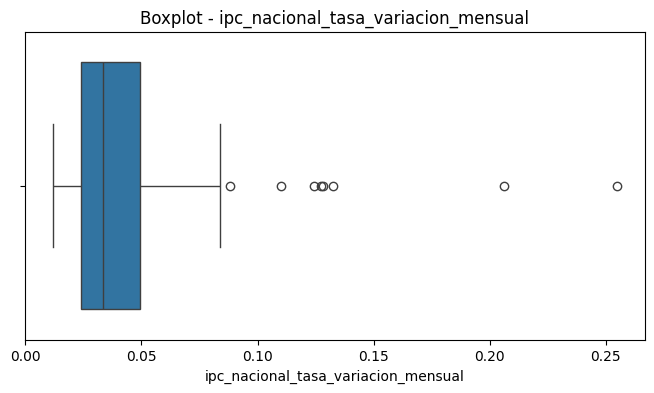

In [95]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_limpieza, x="ipc_nacional_tasa_variacion_mensual")
plt.title("Boxplot - ipc_nacional_tasa_variacion_mensual")
plt.show()

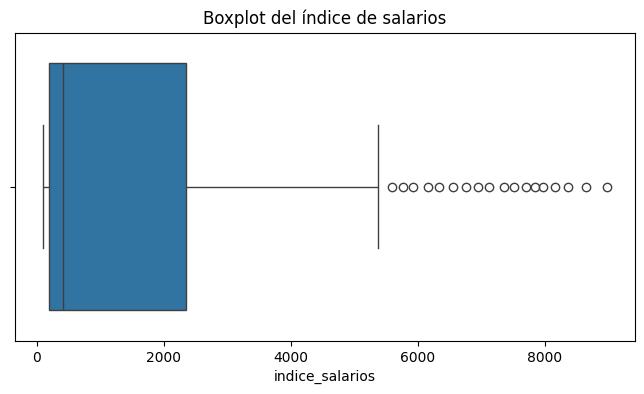

In [92]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_limpieza, x="indice_salarios")
plt.title("Boxplot del índice de salarios")
plt.show()

El boxplot muestra una distribución asimétrica con valores altos identificados como posibles outliers. Sin embargo, dado que se trata de una serie temporal de índices económicos acumulados, estos valores probablemente reflejan el crecimiento natural de la serie y no necesariamente errores en los datos

In [96]:
df_limpieza.nlargest(5, "ipc_nacional_tasa_variacion_mensual")

,indice_tiempo,indice_salarios,indice_salarios_registrado,indice_salarios_registrado_sector_privado,indice_salarios_registrado_sector_publico,indice_salarios_no_registrado_sector_privado,ipc_nacional,ipc_gba,ipc_nacional_tasa_variacion_mensual,ipc_gba_tasa_variacion_mensual
84,2023-12-01,2348.79,2546.20,2648.87,2374.02,1555.65,3533.1922,3456.6426,0.254657,0.250850
85,2024-01-01,2734.97,2985.00,3178.28,2660.85,1730.47,4261.5324,4132.4790,0.206142,0.195518
86,2024-02-01,3099.20,3415.26,3625.42,3062.83,1829.42,4825.7881,4751.2725,0.132407,0.149739
83,2023-11-01,2157.73,2335.04,2385.55,2250.34,1445.34,2816.0628,2763.4350,0.128107,0.129055
81,2023-09-01,1826.29,1964.34,1995.58,1911.97,1271.63,2304.9242,2253.4785,0.127498,0.121799


In [97]:
df_limpieza.nlargest(
    5,
    "ipc_nacional_tasa_variacion_mensual"
)[["indice_tiempo", "ipc_nacional_tasa_variacion_mensual"]]

,indice_tiempo,ipc_nacional_tasa_variacion_mensual
84,2023-12-01,0.254657
85,2024-01-01,0.206142
86,2024-02-01,0.132407
83,2023-11-01,0.128107
81,2023-09-01,0.127498


Se identificaron valores elevados en la tasa de variación mensual del IPC mediante un boxplot. Al inspeccionarlos, se comprobó que corresponden a los meses de diciembre de 2023 y enero de 2024, caracterizados por una inflación mensual excepcionalmente alta. Al tratarse de datos oficiales y coherentes con el contexto económico, se conservaron para el análisis. Podemos ver la tasa de variación mensual del ipc del 12-2023 al 01-2024 aumento respecto el mes anterior un 0,25

In [98]:
df_limpieza[[
    "indice_salarios_registrado",
    "indice_salarios_no_registrado_sector_privado",
    "ipc_nacional"
]].head()

,indice_salarios_registrado,indice_salarios_no_registrado_sector_privado,ipc_nacional
0,102.69,103.20,100.0000
1,104.98,102.00,101.5859
2,105.97,104.94,103.6859
3,108.50,110.08,106.1476
4,112.14,114.61,108.9667


Procedo a analizar si esta normalizado tanto la serie de tiempo la cual ya lo habia hecho con el merge.Sin embargo indice_salarios_registrado no parte de 100 por lo que lo tengo que normalizar a 100 y ipc_nacional si ya parte de 100

In [99]:
df_limpieza[[
    "indice_tiempo",
    "indice_salarios_registrado",
    "ipc_nacional"
]].head(10)

,indice_tiempo,indice_salarios_registrado,ipc_nacional
0,2016-12-01,102.69,100.0000
1,2017-01-01,104.98,101.5859
2,2017-02-01,105.97,103.6859
3,2017-03-01,108.50,106.1476
4,2017-04-01,112.14,108.9667
5,2017-05-01,114.09,110.5301
6,2017-06-01,116.51,111.8477
7,2017-07-01,121.19,113.7852
8,2017-08-01,123.43,115.3819
9,2017-09-01,125.21,117.5719


In [100]:
df_limpieza[[
    "indice_tiempo",
    "indice_salarios_registrado",
    "ipc_nacional"
]].tail()

,indice_tiempo,indice_salarios_registrado,ipc_nacional
108,2025-12-01,7794.68,10121.3715
109,2026-01-01,7952.81,10413.0309
110,2026-02-01,8096.38,10714.6255
111,2026-03-01,8341.11,11077.0608
112,2026-04-01,8628.95,11363.0904


<center>
  <font size="5" color="black">
    <b><u>TRANSFORMACIÓN</u></b>
  </font>
</center>


In [101]:
df_forma = df_limpieza.copy()

###Normalizar ó rebasar el Índice
Se pone iloc[0] y no 102,69 por un tema de si llega a cambiar en algun momento el valor que siempre agarre el primero pese a cualquier cambio

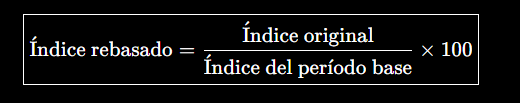

Primero rebasamos de forma que llevemos el primer valor a 100, esto se hace para que el analisis de diferentes variables arranquen apartir del mismo valor, entonces sus movimientos y sus datos se pueden comparar de forma mas efectiva y visible

In [102]:
df_forma["indice_salarios_registrado"] =(
        df_forma["indice_salarios_registrado"] /
        df_forma["indice_salarios_registrado"].iloc[0]
    ) * 100

df_forma["indice_salarios_registrado"]

,indice_salarios_registrado
0,100.000000
1,102.230013
2,103.194079
3,105.657805
4,109.202454
...,...
108,7590.495667
109,7744.483397
110,7884.292531
111,8122.611744


Se crea una nueva columna con los salarios reales registrados

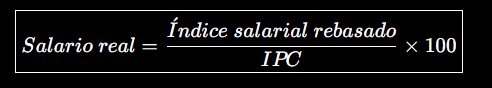

In [103]:
df_forma["salario_real_registrado"] = (df_forma["indice_salarios_registrado"]/
    df_limpieza["ipc_nacional"]
) * 100

df_forma

,indice_tiempo,indice_salarios,indice_salarios_registrado,indice_salarios_registrado_sector_privado,indice_salarios_registrado_sector_publico,indice_salarios_no_registrado_sector_privado,ipc_nacional,ipc_gba,ipc_nacional_tasa_variacion_mensual,ipc_gba_tasa_variacion_mensual,salario_real_registrado
0,2016-12-01,102.79,100.000000,102.89,102.37,103.20,100.0000,100.0000,NaN,NaN,100.000000
1,2017-01-01,104.38,102.230013,106.34,102.68,102.00,101.5859,101.3130,0.015859,0.013130,100.634057
2,2017-02-01,105.76,103.194079,107.69,103.08,104.94,103.6859,103.8085,0.020672,0.024632,99.525663
3,2017-03-01,108.82,105.657805,109.26,107.24,110.08,106.1476,106.2627,0.023742,0.023642,99.538572
4,2017-04-01,112.63,109.202454,112.93,110.81,114.61,108.9667,109.0613,0.026558,0.026337,100.216354
...,...,...,...,...,...,...,...,...,...,...,...
108,2025-12-01,7969.60,7590.495667,8441.00,6710.79,8672.31,10121.3715,10115.6707,0.028453,0.027927,74.994734
109,2026-01-01,8171.66,7744.483397,8620.98,6832.27,9050.90,10413.0309,10395.7458,0.028816,0.027687,74.372999
110,2026-02-01,8370.04,7884.292531,8755.26,6991.42,9469.49,10714.6255,10667.6896,0.028963,0.026159,73.584397
111,2026-03-01,8654.99,8122.611744,8935.48,7344.33,9916.02,11077.0608,11031.5404,0.033826,0.034108,73.328222


In [104]:
df_forma["indice_salarios_no_registrado_sector_privado"] =(
        df_forma["indice_salarios_no_registrado_sector_privado"] /
        df_forma["indice_salarios_no_registrado_sector_privado"].iloc[0]
    ) * 100

df_forma["indice_salarios_no_registrado_sector_privado"]

,indice_salarios_no_registrado_sector_privado
0,100.000000
1,98.837209
2,101.686047
3,106.666667
4,111.056202
...,...
108,8403.401163
109,8770.251938
110,9175.862403
111,9608.546512


In [105]:
df_forma["salario_real_no_registrado"] = (df_forma["indice_salarios_no_registrado_sector_privado"]/
    df_limpieza["ipc_nacional"]
) * 100

df_forma["salario_real_no_registrado"]

,salario_real_no_registrado
0,100.000000
1,97.294220
2,98.071239
3,100.489005
4,101.917560
...,...
108,83.026309
109,84.223816
110,85.638667
111,86.742744


In [106]:
df_forma[[
    "salario_real_registrado",
    "salario_real_no_registrado"
]].describe()

,salario_real_registrado,salario_real_no_registrado
count,113.000000,113.000000
mean,84.893371,75.553708
std,9.042976,17.724712
min,68.210367,35.962007
25%,76.918356,64.523247
50%,83.368274,76.723350
75%,88.778273,87.152230
max,104.172932,105.866832


###Variacion de un mes a otro mes
La idea es que se muestre cuánto cambió porcentualmente el salario real registrado y no registrado respecto al primer período de la serie.
Cuandola variacion real da negativa quiere decir que el salario real disminuyo respecto al que tome como referencia en este caso 100

In [107]:
df_forma["variacion_real_registrado"] = (
    (df_forma["salario_real_registrado"] /
     df_forma["salario_real_registrado"].iloc[0]) - 1
) * 100

In [108]:
print(df_forma[["indice_tiempo", "salario_real_registrado", "variacion_real_registrado" ]].head())

  indice_tiempo  salario_real_registrado  variacion_real_registrado
0    2016-12-01               100.000000                   0.000000
1    2017-01-01               100.634057                   0.634057
2    2017-02-01                99.525663                  -0.474337
3    2017-03-01                99.538572                  -0.461428
4    2017-04-01               100.216354                   0.216354


In [109]:
df_forma["variacion_real_no_registrado"] = (
    (df_forma["salario_real_no_registrado"] /
     df_forma["salario_real_no_registrado"].iloc[0]) - 1
) * 100

In [110]:
print(df_forma[["indice_tiempo", "salario_real_no_registrado", "variacion_real_no_registrado" ]].head())

  indice_tiempo  salario_real_no_registrado  variacion_real_no_registrado
0    2016-12-01                  100.000000                      0.000000
1    2017-01-01                   97.294220                     -2.705780
2    2017-02-01                   98.071239                     -1.928761
3    2017-03-01                  100.489005                      0.489005
4    2017-04-01                  101.917560                      1.917560


Si solo quisiera medir el 2025

In [111]:
df_2025 = df_forma[
    df_forma["indice_tiempo"].dt.year == 2025
].copy()

<center>
  <font size="5" color="black">
    <b><u>ANÁLISIS</u></b>
  </font>
</center>


In [112]:
df_analisis = df_forma.copy()

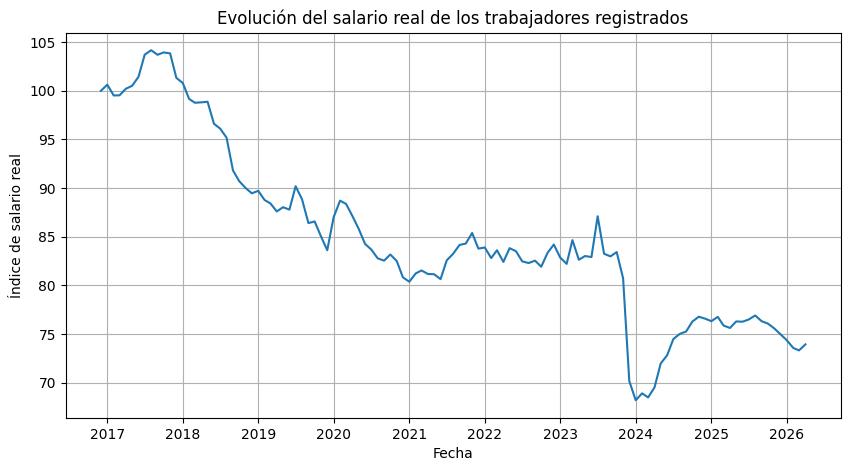

In [113]:
plt.figure(figsize=(10,5))

plt.plot(
    df_analisis["indice_tiempo"],
    df_analisis["salario_real_registrado"]
)

plt.title("Evolución del salario real de los trabajadores registrados")
plt.xlabel("Fecha")
plt.ylabel("Índice de salario real")
plt.grid(True)

plt.show()

La tendencia general es decreciente.
Desde el periodo de 2018 a 2021 el salario real de los registrados esta en constante caida.
Luego ocurre una caida muy fuerte en el año 2024 con una caida con bajos historicos y se va recuperando para el 2025 a 2026

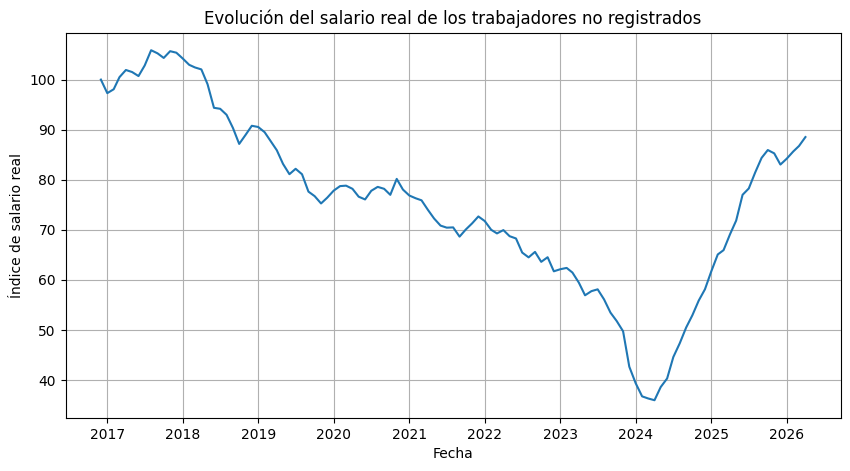

In [114]:
plt.figure(figsize=(10,5))

plt.plot(
    df_analisis["indice_tiempo"],
    df_analisis["salario_real_no_registrado"]
)

plt.title("Evolución del salario real de los trabajadores no registrados")
plt.xlabel("Fecha")
plt.ylabel("Índice de salario real")
plt.grid(True)

plt.show()

La tendencia general es decreciente pero en los dos ultimos años hay tendencia al alza de parte de los no registrados. En el intervalo de 2018 a 2024 esta en constante decrecimiento, no obstante, en 2025 a 2026 hay una fuerte alza de modo creciente que estaria alcanzando al maximo historico de sguguir con esa alza

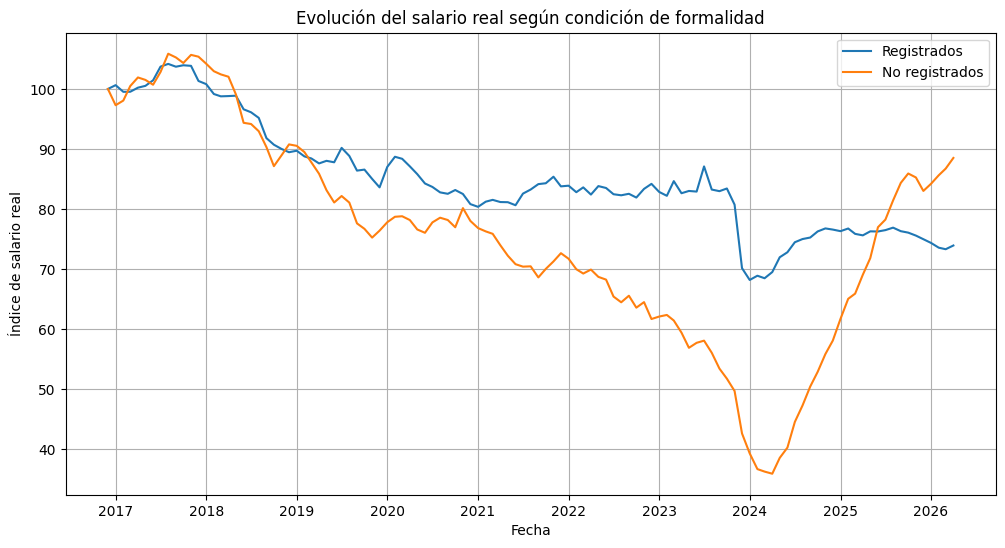

In [115]:
plt.figure(figsize=(12,6))

plt.plot(
    df_analisis["indice_tiempo"],
    df_analisis["salario_real_registrado"],
    label="Registrados"
)

plt.plot(
    df_analisis["indice_tiempo"],
    df_analisis["salario_real_no_registrado"],
    label="No registrados"
)

plt.title("Evolución del salario real según condición de formalidad")
plt.xlabel("Fecha")
plt.ylabel("Índice de salario real")
plt.legend()
plt.grid(True)

plt.show()

* 2017–2019: Los salarios reales de trabajadores registrados y no registrados presentan una evolución similar. Ambas series muestran aumentos y disminuciones a lo largo del período, sin una separación marcada entre ellas.

* 2019–2024: Se observa una caída más pronunciada del salario real de los trabajadores no registrados. En estos años, la diferencia entre ambos grupos se amplía progresivamente, lo que indica que los trabajadores informales perdieron poder adquisitivo en mayor medida que los registrados.

* 2024–2025: El salario real de los trabajadores no registrados muestra una recuperación importante, reduciendo rápidamente la brecha con los trabajadores registrados.
cia el final del período, el salario real de los trabajadores no registrados alcanza e incluso supera al de los trabajadores registrados, evidenciando un cambio en la tendencia observada durante los años anteriores.
* 2025–2026: Hacia el final del período, el salario real de los trabajadores no registrados alcanza e incluso supera al de los trabajadores registrados, evidenciando un cambio en la tendencia observada durante los años anteriores.


In [126]:
fig = px.line(
    df_analisis,
    x="indice_tiempo",
    y=[
        "salario_real_registrado",
        "salario_real_no_registrado"
    ],
    title="Evolución del salario real según condición de formalidad",
    labels={
        "indice_tiempo": "Fecha",
        "value": "Índice de salario real",
        "variable": "Condición laboral"
    }, width = 1100, height = 500
)

fig.show()

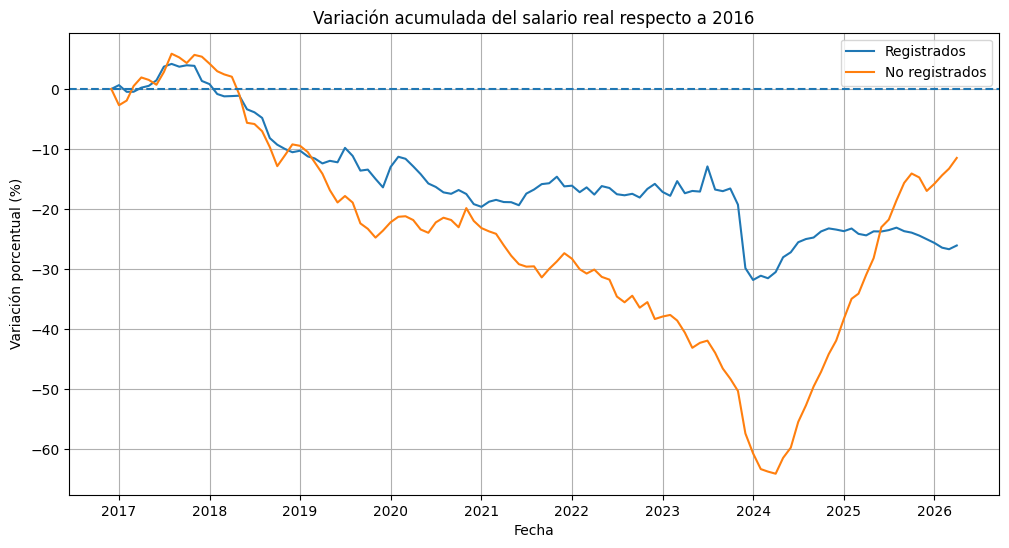

In [128]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_analisis["indice_tiempo"],
    df_analisis["variacion_real_registrado"],
    label="Registrados"
)

plt.plot(
    df_analisis["indice_tiempo"],
    df_analisis["variacion_real_no_registrado"],
    label="No registrados"
)

plt.axhline(0, linestyle="--")

plt.title("Variación acumulada del salario real respecto a 2016")
plt.xlabel("Fecha")
plt.ylabel("Variación porcentual (%)")
plt.legend()
plt.grid(True)

plt.show()

En esta parte queria ver el salario real solo en el año 2025

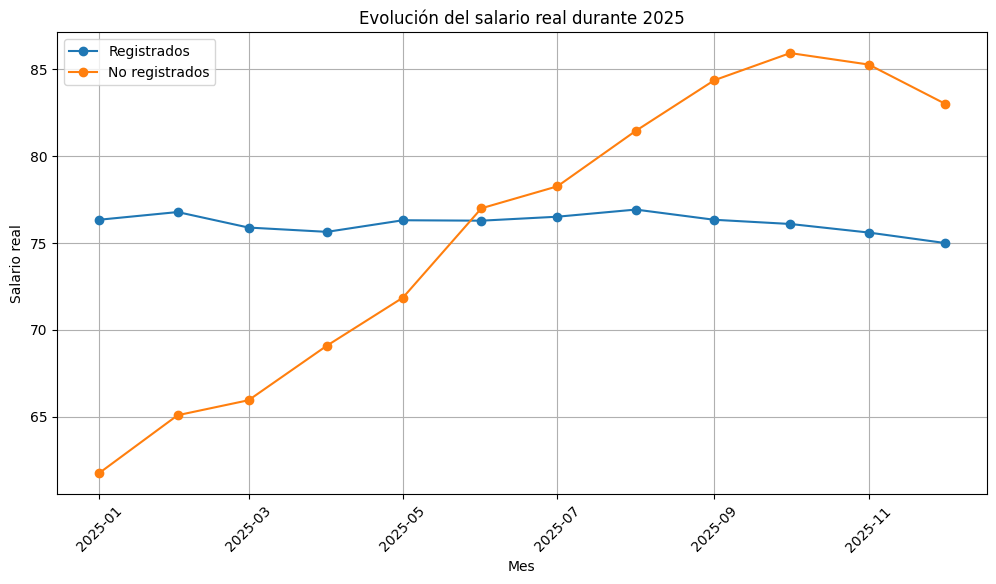

In [118]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_2025["indice_tiempo"],
    df_2025["salario_real_registrado"],
    marker="o",
    label="Registrados"
)

plt.plot(
    df_2025["indice_tiempo"],
    df_2025["salario_real_no_registrado"],
    marker="o",
    label="No registrados"
)

plt.title("Evolución del salario real durante 2025")
plt.xlabel("Mes")
plt.ylabel("Salario real")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

En esta parte queria ver solo la variacion del salario real en 2025 pero primero tuve que usar el .melt porque como las fechas de las variaciones suelen coincidir le tengo que indicar que son dos variables diferentes

In [119]:
df_2025_largo = df_2025.melt(
    id_vars="indice_tiempo",
    value_vars=[
        "variacion_real_registrado",
        "variacion_real_no_registrado"
    ],
    var_name="tipo_trabajador",
    value_name="variacion"
)

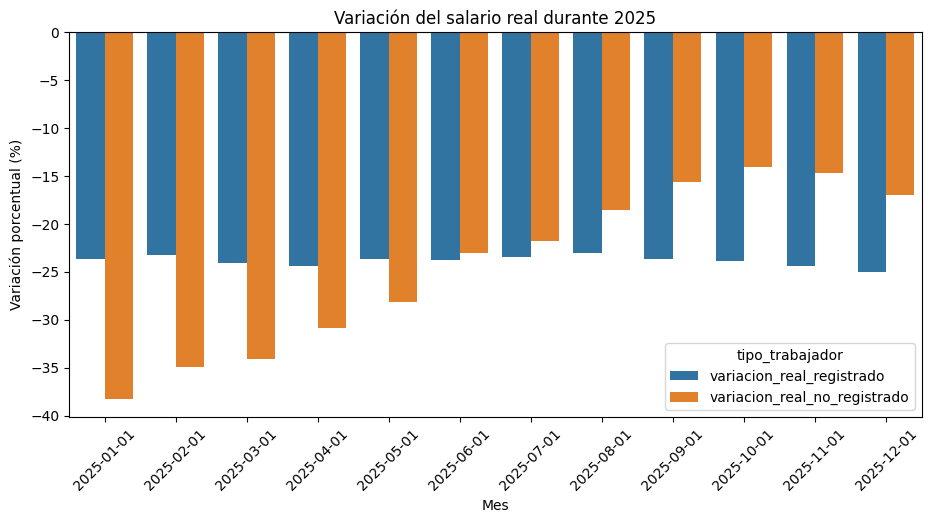

In [120]:
plt.figure(figsize=(11, 5))
sns.barplot(
    data=df_2025_largo,
    x="indice_tiempo",
    y="variacion",
    hue="tipo_trabajador"
)

plt.title("Variación del salario real durante 2025")
plt.xlabel("Mes")
plt.ylabel("Variación porcentual (%)")
plt.xticks(rotation=45)
plt.axhline(0, linestyle="--")

plt.show()

<center>
  <font size="5" color="black">
    <b><u>PREGUNTA Y SOLUCIÓN DEL ANÁLISIS </u></b>
  </font>
</center>


**¿En qué medida la inflación acumulada afectó el poder adquisitivo de los trabajadores registrados e informales?**
La inflación no afectó de manera uniforme a ambos grupos.

Entre 2019 y 2024, los trabajadores no registrados experimentaron una mayor pérdida de poder adquisitivo.

A partir de 2024, esa tendencia se revierte y los trabajadores no registrados recuperan terreno, llegando incluso a superar a los registrados al final del período.

Sin embaro esta respuesta se queda corta porque para que podamos medir bien la inflación necesitamos medir los salarios con el ipc.


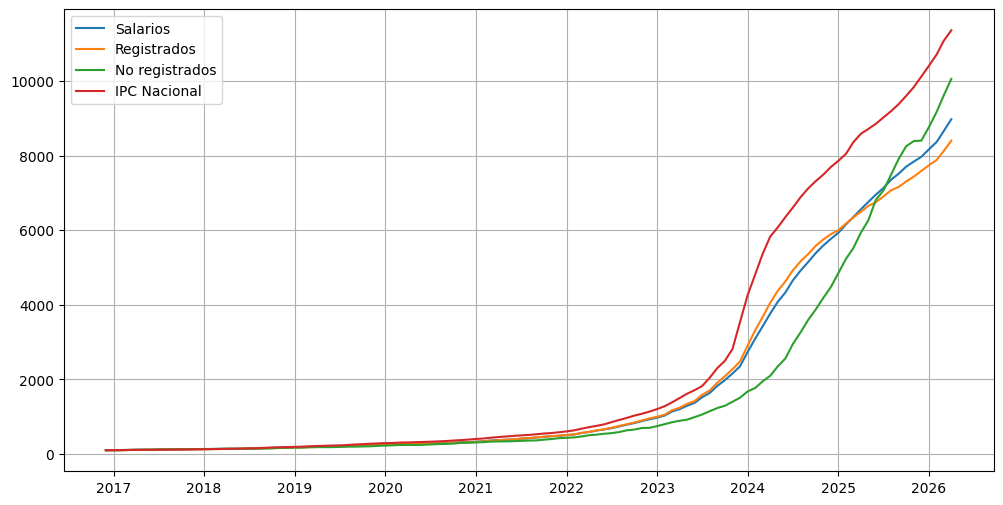

In [121]:
plt.figure(figsize=(12,6))

plt.plot(df_analisis["indice_tiempo"], df_analisis["indice_salarios"], label="Salarios")
plt.plot(df_analisis["indice_tiempo"], df_analisis["indice_salarios_registrado"], label="Registrados")
plt.plot(df_analisis["indice_tiempo"], df_analisis["indice_salarios_no_registrado_sector_privado"], label="No registrados")
plt.plot(df_analisis["indice_tiempo"], df_analisis["ipc_nacional"], label="IPC Nacional")

plt.legend()
plt.grid(True)
plt.show()

Este grafico tiene los salarios nominales, ya que el salario real venia calculado con el ipc y seria contraproducente analizarlo con el ipc

En este grafico podemos ver como los salarios nominales se alejan cada vez mas del ipc.Durante los períodos en los que el crecimiento de los salarios nominales se ubicó por debajo del aumento del IPC, los trabajadores experimentaron una pérdida de poder adquisitivo. Esto significa que, aunque los salarios nominales hayan aumentado en términos monetarios, su capacidad para adquirir bienes y servicios se redujo debido a que los precios crecieron a un ritmo superior.
.Entonces aca nos damos cuenta que la inflacion fue afectando cada vez mas a los trabajadores tanto formales como informales pese a su recuperación

In [122]:
df_analisis["brecha_salario_real"] = (
    df_analisis["salario_real_registrado"] -
    df_analisis["salario_real_no_registrado"]
)

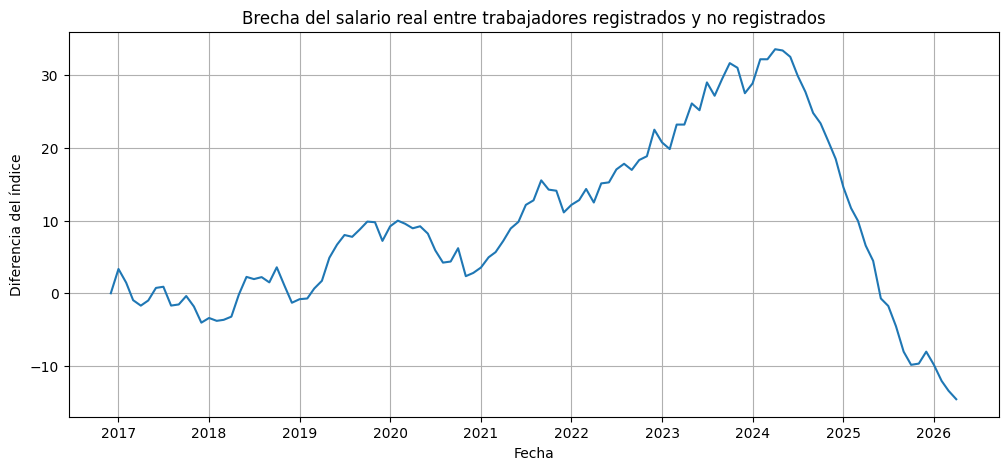

In [123]:
plt.figure(figsize=(12,5))

plt.plot(
    df_analisis["indice_tiempo"],
    df_analisis["brecha_salario_real"]
)

plt.title("Brecha del salario real entre trabajadores registrados y no registrados")
plt.xlabel("Fecha")
plt.ylabel("Diferencia del índice")
plt.grid(True)

plt.show()

cada punto del gráfico te dice cuánta diferencia había entre ambos salarios reales en ese mes.

* Si la brecha sube, significa que la diferencia entre registrados y no registrados aumenta (los registrados tienen relativamente mayor salario real).

* Si la brecha baja, significa que esa diferencia se reduce.

* Si la brecha llega a 0, ambos grupos tienen el mismo salario real.

* Si la brecha pasa a ser negativa, significa que el salario real de los no registrados superó al de los registrados.